# PRCP-1020-Housing Price Prediction

## Objectives

**1. Exploratory Data Analysis**  
Thoroughly understand the dataset: quality, distributions, correlations, missing values, and outliers.

**2. Modeling & Interpretation**    
Build accurate, robust models to predict house price.  
Quantify and explain how features influence price .

**3. Actionable Recommendations**  
provide buyer guidance  

**Metric**: RMSE, R² Score  
**Dataset**: Ames Housing Datast  
.

## Reading the Data

In [52]:
BASE_DIR = os.getcwd() # getting the location of base directory
DATA_PATH = os.path.join(BASE_DIR,"Data","data.csv") # getting the location of dataset

df = pd.read_csv(DATA_PATH) # reading the csv file

In [51]:
# core libraries
import os
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

# saving the model
import joblib

# warnings
import warnings
warnings.filterwarnings("ignore")

# pandas setup
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)

## 1. Exploratory Data Analysis

In [53]:
df.shape # numnber of rows and number of columns

(1460, 81)

In [54]:
df.info() # gives number of non-null count and datatype of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [55]:
df.head(6)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000


#### Changing the datatype

In [56]:
# one of the categorical features (MSSubClass) is given int64 datatype 
# instead of object datatype
df['MSSubClass'] = df['MSSubClass'].astype('object')  # changing datatype to object

In [57]:
# to verify change to object datatype
df['MSSubClass'].dtypes

dtype('O')

In [58]:
df.columns # fetching the column names

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [59]:
df.describe().T # statistcal analysis of columns

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


### Target Variable Analysis

Skewness: 1.8828757597682129


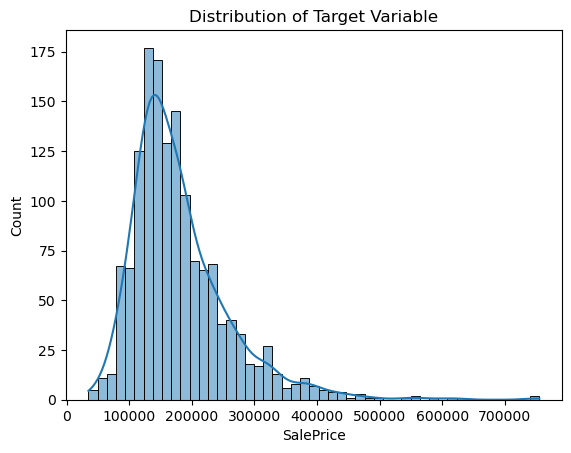

In [60]:
# pltting histogram
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of Target Variable")
#check skewness
print("Skewness:", df['SalePrice'].skew())

The skew value of 1.882, tells that the SalePrice variable is highly right skewed, which is againt the assumptions of linear models.  
Therefore its preferable to use tree-based ensemble models for best results

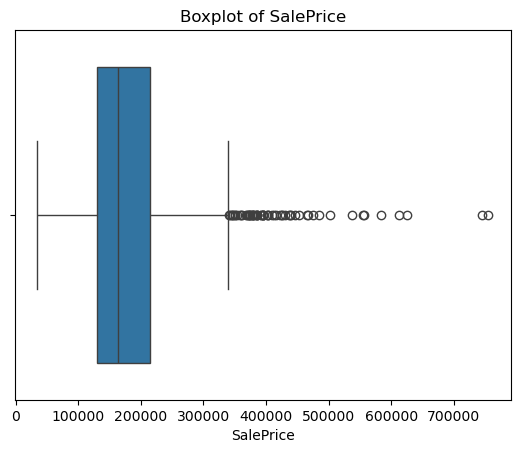

In [61]:
sns.boxplot(x=df['SalePrice'])
plt.title("Boxplot of SalePrice")
plt.show()

Outliers are present that may distort regression

### Univariate Analysis of numerical features

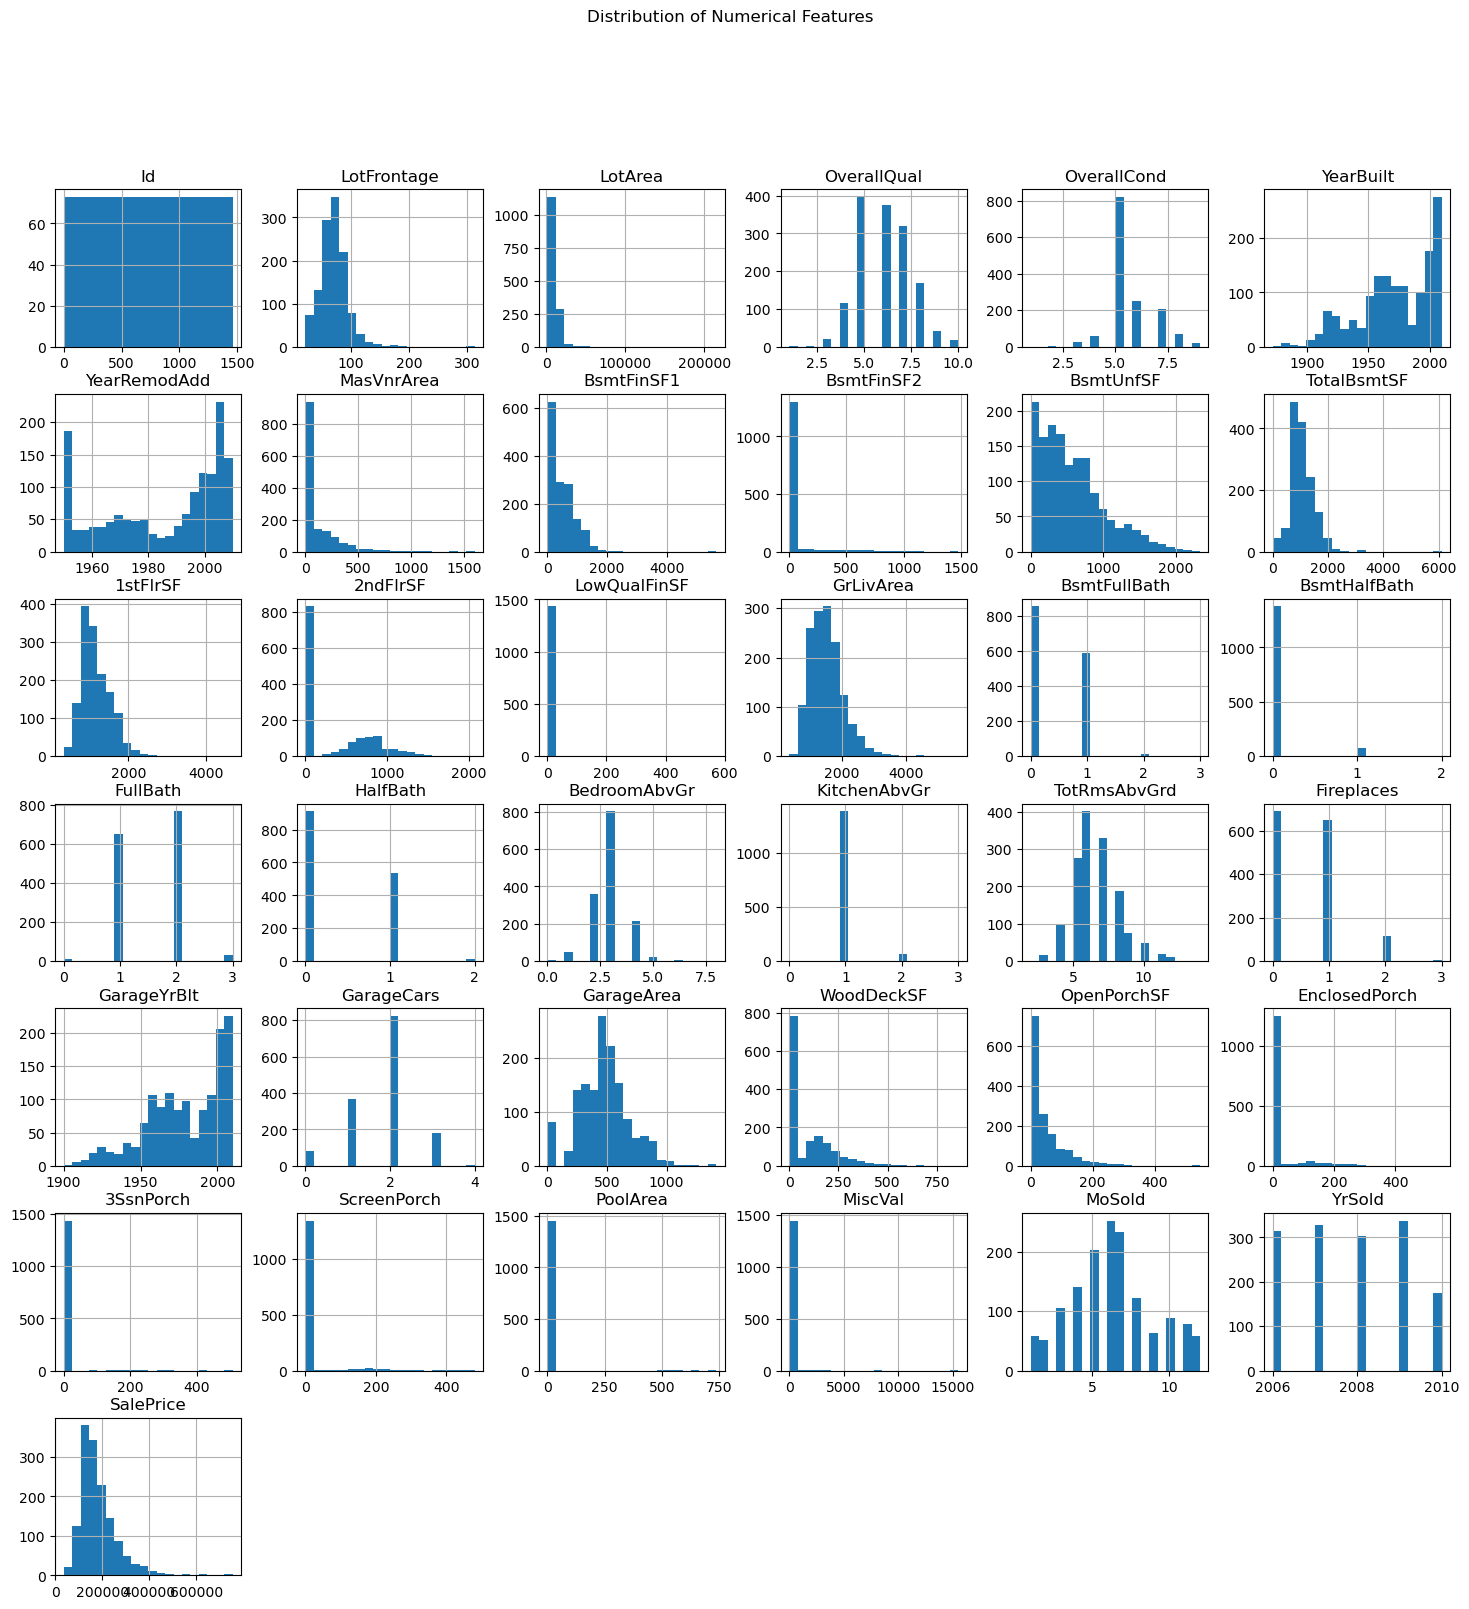

In [62]:
num_features = df.select_dtypes(include=np.number).columns.tolist()

df[num_features].hist(bins=20, figsize=(18,18))
plt.suptitle("Distribution of Numerical Features")
plt.show()

All numerical features are skewed and has scale differences

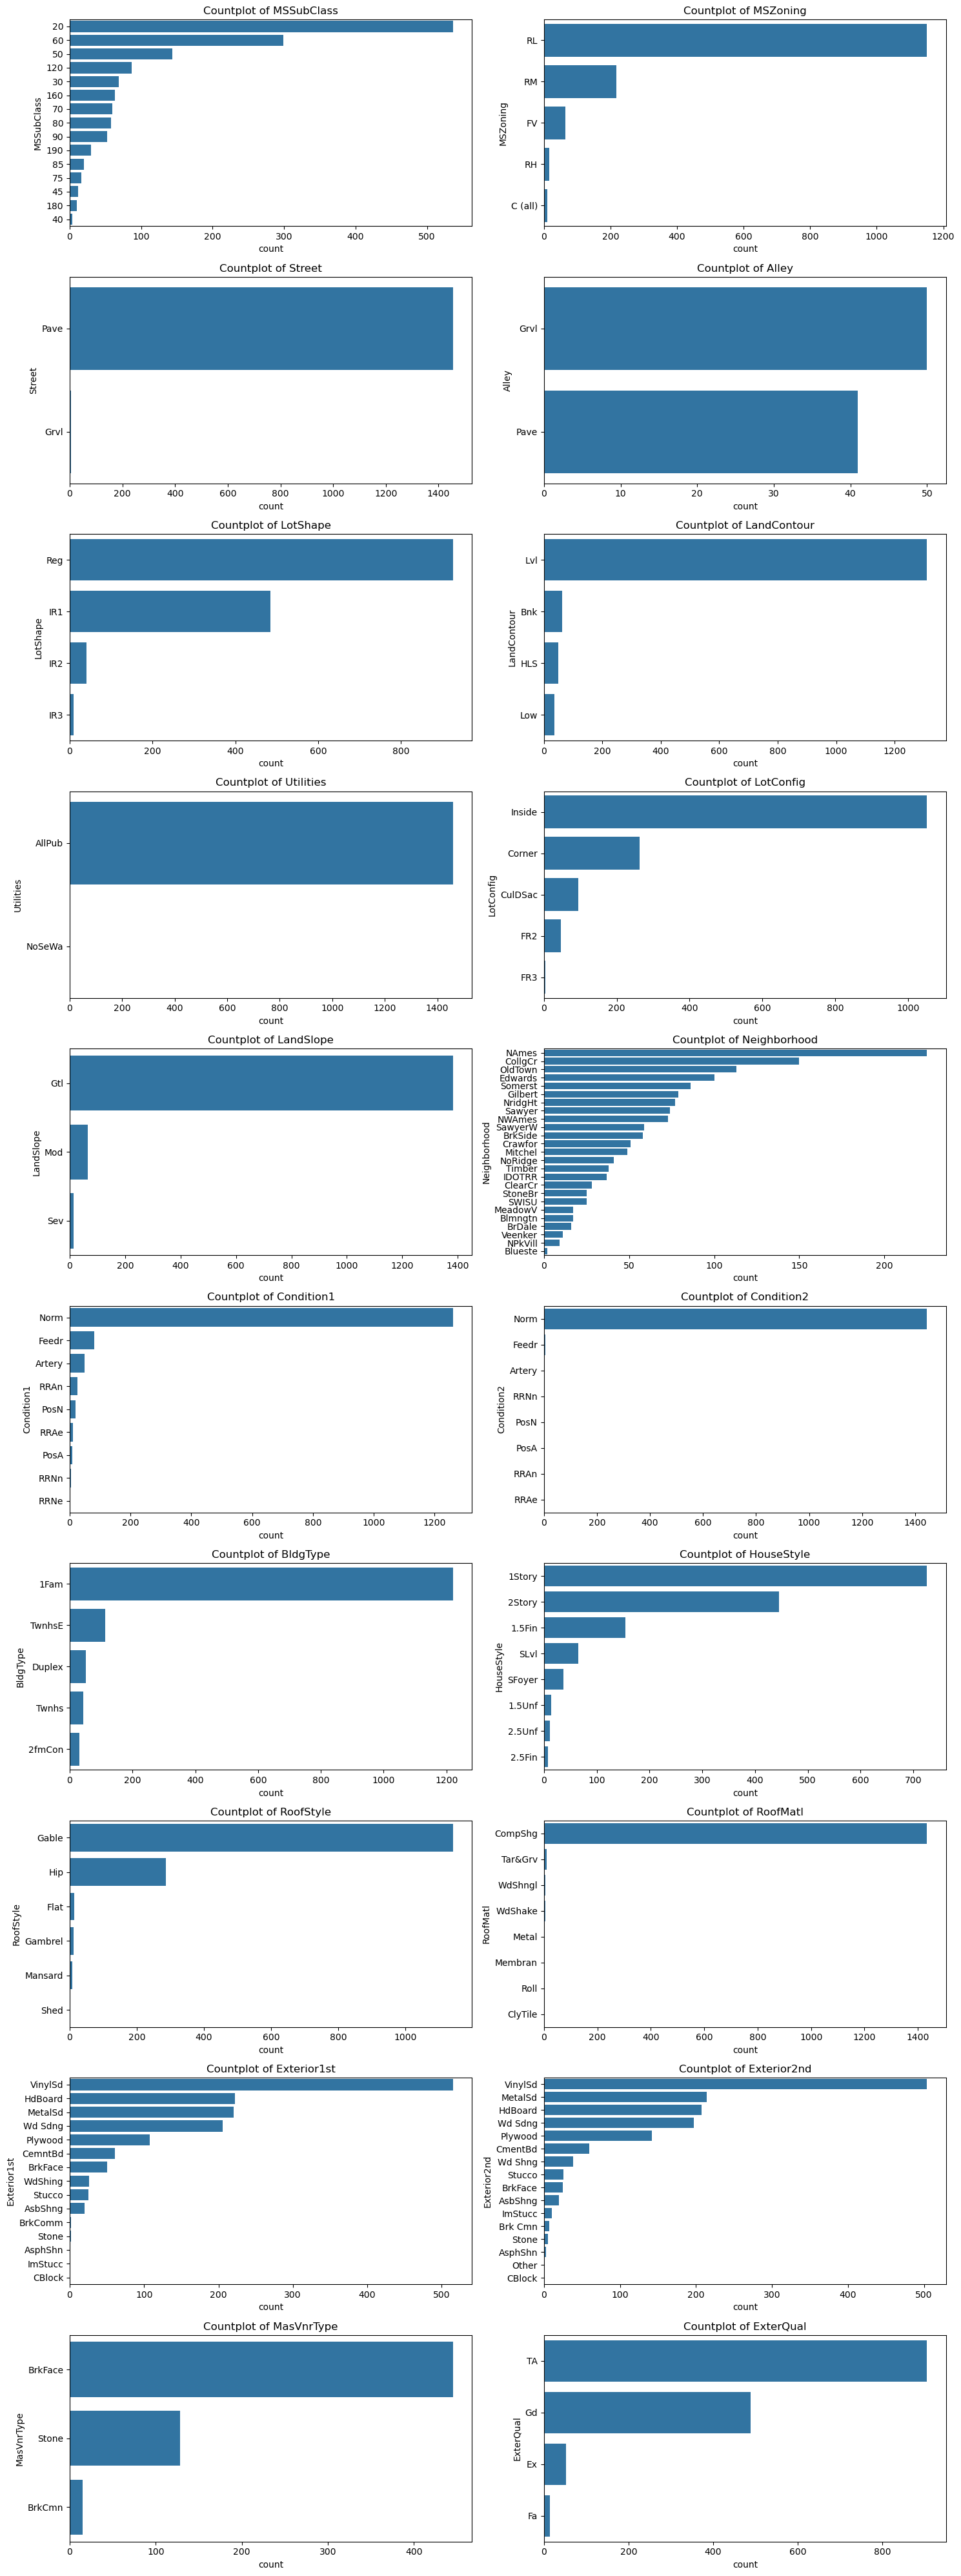

In [63]:
cat_features = df.select_dtypes(exclude=np.number).columns.tolist()

plt.figure(figsize=(15, 40))
for i, col in enumerate(cat_features[:20]):  # limit to first 20 for readability
    plt.subplot(10, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
plt.tight_layout()
plt.show()

Most the categorical features have dominant categories

### Bivariate Analysis (Feature vs Target)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


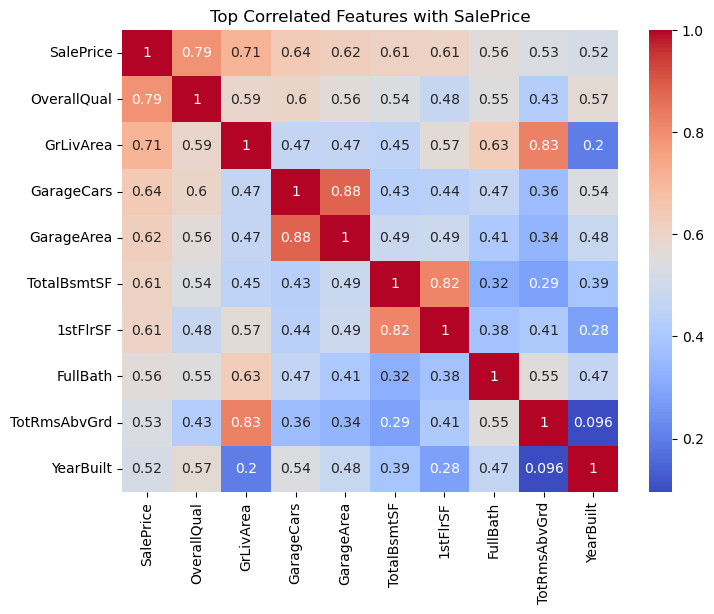

In [64]:
# Correlation of highly correlated 10 numerical features
top_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10)
print(top_corr)
plt.figure(figsize=(8,6))
sns.heatmap(df[top_corr.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Correlated Features with SalePrice")
plt.show()

Some features exhibit strong multicolinearity, can cause interpretability issues

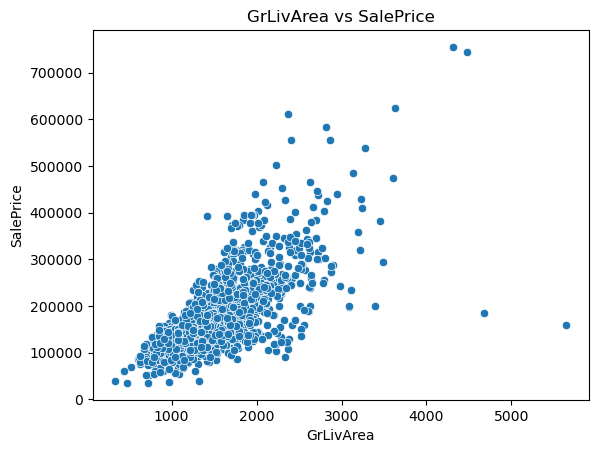

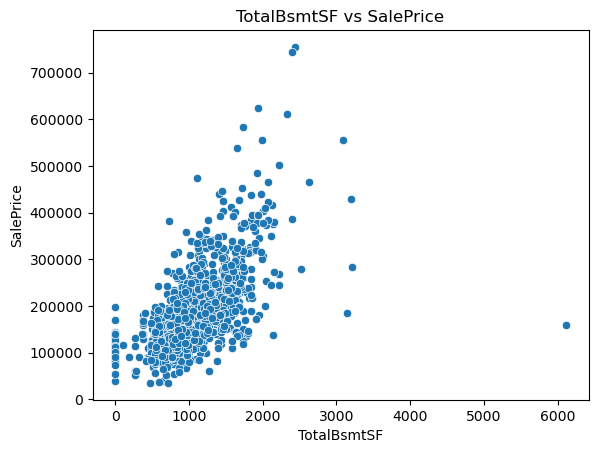

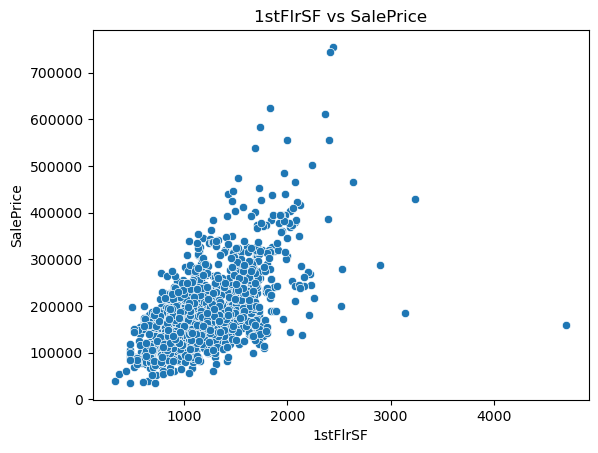

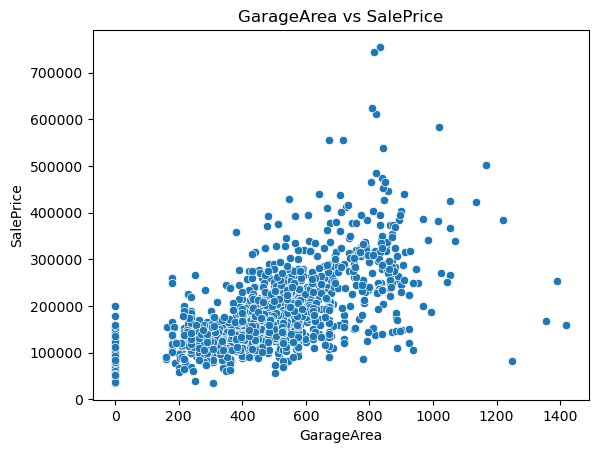

In [65]:
# Scatterplots for top continous numerical features
for col in ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']:
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.show()

Scatter plots of continous numerical features like GrLivArea, TotalBsmtSF, 1stFlrSF, GarageArea , shows strong correlation with SalesPrice. The plot also reveals the presence of outliers that can distort regression models.

### Categories vs Target

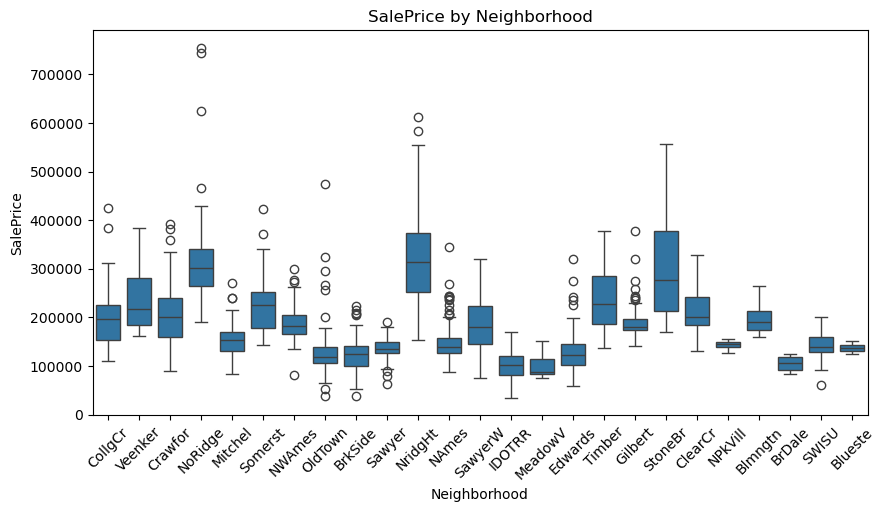

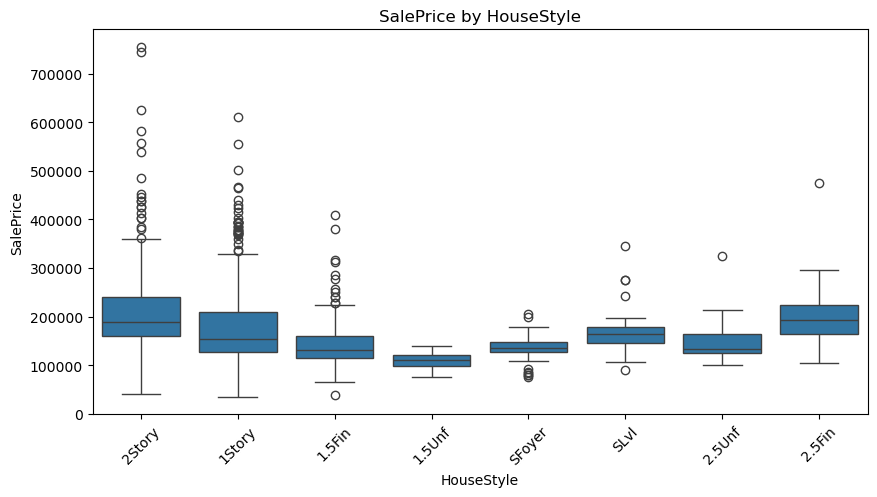

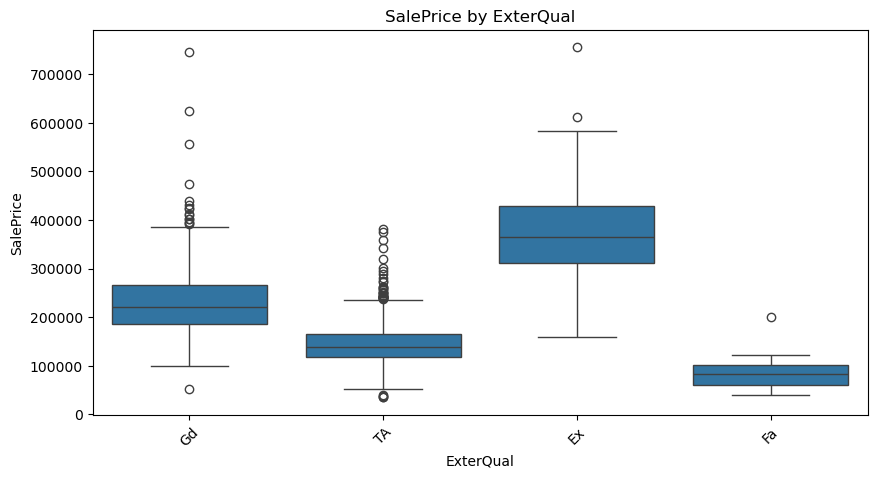

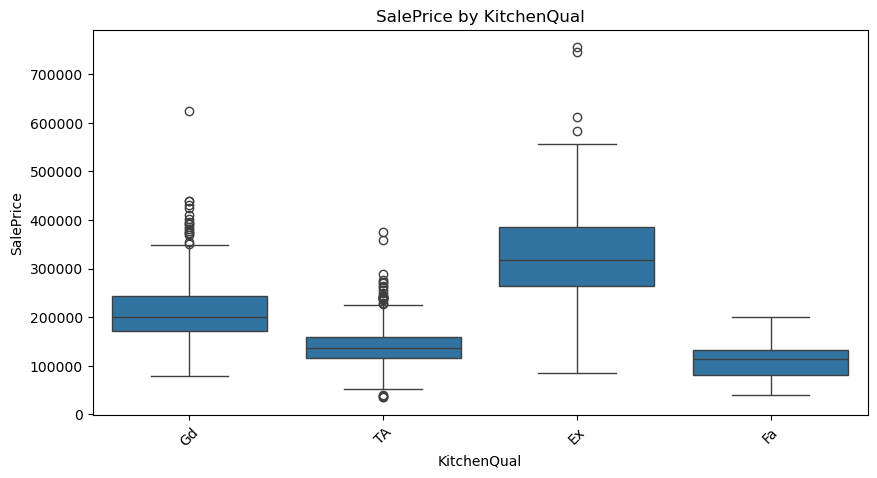

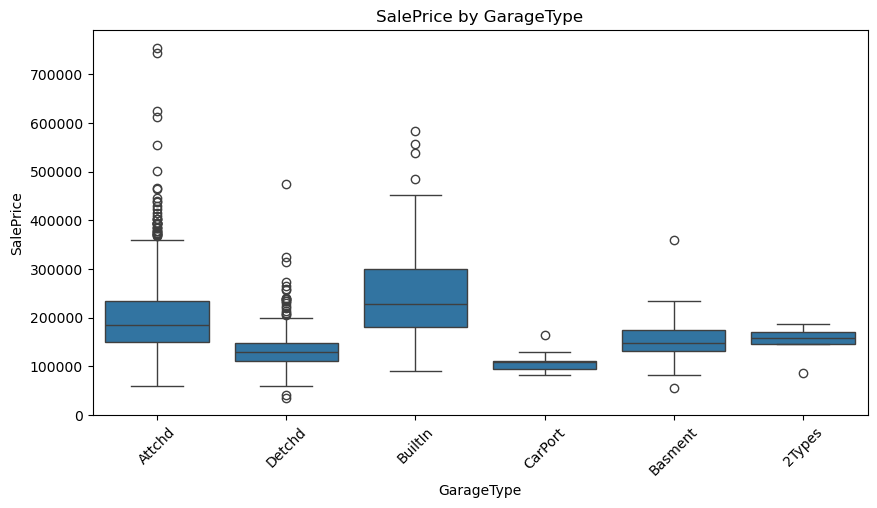

In [66]:
categorical_to_check = ['Neighborhood', 'HouseStyle', 'ExterQual', 'KitchenQual', 'GarageType']

for col in categorical_to_check:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.title(f"SalePrice by {col}")
    plt.xticks(rotation=45)
    plt.show()


The boxplots reveal that certain categories in categorical features has strong influence on Sales Price.

### Missing Values Visualization

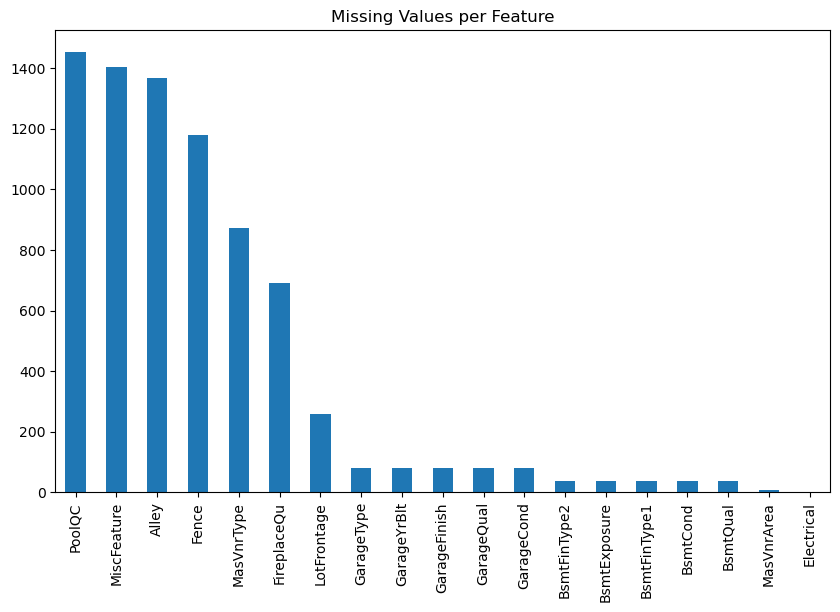

In [67]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(10,6))
missing.plot(kind='bar')
plt.title("Missing Values per Feature")
plt.show()

Some columns contain significant level of missing values and it has to be dropped whereas some column with fewer missing values can be considered for imputation

## Handling Missing Values

In [68]:
# number of missing values in each column in descending order
df.isnull().sum().sort_values(ascending=False).head(25) 

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
Functional         0
Fireplaces         0
KitchenQual        0
KitchenAbvGr       0
BedroomAbvGr       0
dtype: int64

In [69]:
# percentage of missing values in each column
df.isnull().mean().sort_values(ascending=False).head(25)*100 

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Id               0.000000
Functional       0.000000
Fireplaces       0.000000
KitchenQual      0.000000
KitchenAbvGr     0.000000
BedroomAbvGr     0.000000
dtype: float64

In [70]:
# Colummns that has more than 30% missing values
missing_percent = df.isnull().mean() * 100
missing_percent[missing_percent > 30].sort_values(ascending=False)

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
FireplaceQu    47.260274
dtype: float64

In [71]:
#removing the columns that has more than 30% missing values
df = df.dropna(axis=1, thresh=0.7*len(df))  

In [72]:
# we still have some columns with missing values
df.isnull().sum().sort_values(ascending=False).head(18)

LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
GarageFinish     81
GarageQual       81
BsmtFinType2     38
BsmtExposure     38
BsmtFinType1     37
BsmtCond         37
BsmtQual         37
MasVnrArea        8
Electrical        1
WoodDeckSF        0
PavedDrive        0
LowQualFinSF      0
GrLivArea         0
BsmtFullBath      0
dtype: int64

In [73]:
# separating numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [74]:
# list of numerical columns
num_cols 

Index(['Id', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [75]:
# list of categorical columns
cat_cols

Index(['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [76]:
# Imputing missing values

# Numerical columns are imputed with median of the column - skewed distribution
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# categorical columns are imputed with mode of the column
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [77]:
# making sure all the missing values are imputed
df.isnull().sum().sort_values(ascending=False).head(5)

Id              0
GarageYrBlt     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
dtype: int64

### Dropping the `Id` column because it is not related to target variable

In [78]:
#dropping the Id column
df = df.drop(columns=['Id'])
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [79]:
df.shape

(1460, 74)

Now that we are left with 1460 records and 74 columns including the target `SalePrice` column

## 2. Modelling and Interpretation

### Features and target

In [80]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
print(X.shape)
print(y.shape)

(1460, 73)
(1460,)


## Feature Engineering

### Encoding categorical variables

In [81]:
# Selecting only categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist() # list of categorical variables
numerical_cols = X.select_dtypes(exclude='object').columns.tolist() # list of numerical variables

In [82]:
len(numerical_cols)+len(categorical_cols) # total columns

73

In [83]:
# displaying unique values and its counts in each column
for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of unique categories: {df[col].nunique()}")
    print("Category counts:")
    print(df[col].value_counts())
    print("-----------------------------------")

Column: MSSubClass
Number of unique categories: 15
Category counts:
MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64
-----------------------------------
Column: MSZoning
Number of unique categories: 5
Category counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
-----------------------------------
Column: Street
Number of unique categories: 2
Category counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
-----------------------------------
Column: LotShape
Number of unique categories: 4
Category counts:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
-----------------------------------
Column: LandContour
Number of unique categories: 4
Category counts:
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count,

In [84]:
# Number of categorical columns
#len(cat_cols)

print("categorical")
print(categorical_cols)
print("\ntotal numner of categorical columns",len(categorical_cols))

categorical
['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

total numner of categorical columns 38


#### Defining ordinal columns and thier order

In [85]:
# list of ordinal columns
ordinal_cols = [
    'LotShape', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 
    'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive'
]
# getting the list of nominal columns using list comprehenstion
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

#ordinal categories orders
LotShape_order = ['IR3', 'IR2', 'IR1', 'Reg']
Utilities_order = ['ELO', 'NoSeWa', 'NoSewr', 'AllPub']
LandSlope_order = ['Sev', 'Mod', 'Gtl']
ExterQual_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
ExterCond_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
BsmtQual_order = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
BsmtCond_order = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
BsmtExposure_order = ['NA', 'No', 'Mn', 'Av', 'Gd']
BsmtFinType1_order = ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
BsmtFinType2_order = ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
HeatingQC_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
Electrical_order = ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr']
KitchenQual_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
Functional_order = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
GarageFinish_order = ['NA', 'Unf', 'RFn', 'Fin']
GarageQual_order = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
GarageCond_order = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
PavedDrive_order = ['N', 'P', 'Y']

# list of lists of category orders for ordinal transformer
categories = [
    LotShape_order, Utilities_order, LandSlope_order, ExterQual_order, ExterCond_order,
    BsmtQual_order, BsmtCond_order, BsmtExposure_order, BsmtFinType1_order, BsmtFinType2_order,
    HeatingQC_order, Electrical_order, KitchenQual_order, Functional_order,
    GarageFinish_order, GarageQual_order, GarageCond_order, PavedDrive_order
]

In [86]:
print(nominal_cols)
print("\nnumber of nominal columns",len(nominal_cols))

['MSSubClass', 'MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'GarageType', 'SaleType', 'SaleCondition']

number of nominal columns 20


In [87]:
# instantiating transformers
ordinal_transformer = OrdinalEncoder(categories=categories,
                                     handle_unknown='use_encoded_value',
                                     unknown_value=-1) # unknown parameters tells encoder to assign a specific value
                                                       # for categories that are not present in the training data 
nominal_transformer = OneHotEncoder(handle_unknown='ignore',
                                    sparse_output=False) # unknown parameter gives all zeros for one-hot encoded
                                                         # category coloumns for unseen categories

numeric_transformer = StandardScaler()

#defining the prerocessor
preprocessor  = ColumnTransformer(transformers=[
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('num', numeric_transformer, numerical_cols)
])

## Train-test split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 73)
(292, 73)
(1168,)
(292,)


## Defining models to compare

In [90]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'DecisionTree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
}

## Train and Evaluate models

In [91]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values(by='RMSE', ascending=True)
print(results_df)

              Model          RMSE            R2
6           XGBoost  2.430516e+04  9.229836e-01
5  GradientBoosting  2.776485e+04  8.994975e-01
4      RandomForest  2.846392e+04  8.943728e-01
2             Lasso  3.016512e+04  8.813695e-01
1             Ridge  3.073562e+04  8.768399e-01
3      DecisionTree  3.941832e+04  7.974266e-01
0  LinearRegression  1.346195e+13 -2.362664e+16


### Model Comparison

In [92]:
results_df

,Model,RMSE,R2
6,XGBoost,2.430516e+04,9.229836e-01
5,GradientBoosting,2.776485e+04,8.994975e-01
4,RandomForest,2.846392e+04,8.943728e-01
2,Lasso,3.016512e+04,8.813695e-01
1,Ridge,3.073562e+04,8.768399e-01
3,DecisionTree,3.941832e+04,7.974266e-01
0,LinearRegression,1.346195e+13,-2.362664e+16


#### Selecting the best model (based on RMSE)

In [93]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

Best model: XGBoost


### Hyperparameter Tuning of the Best Model 

In [94]:
# Define pipeline
# pipe = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBRegressor(random_state=42))
# ])

# Define parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 1.0]
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV R²: 0.8789


### Training the model with best hyperparameters

In [45]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")


Test RMSE: 23557.56
Test R²: 0.9276


**On average, your predictions are off by about 23557  
The model explains ~92.76% of the variance in house prices.**

### Saving the model

In [46]:
joblib.dump(best_model, 'best_ames_pipeline_tuned.pkl')
print("Tuned model saved successfully!")

Tuned model saved successfully!


### Extracting Feature importance from XGBoost by Permutaion Importance  
Permutation importance quantifies how much the model's predictive performance drops when the values of a single feature are randomly shuffled.  
So if shuffling a feature causes a big drop in model preformance, that feature is important.

In [48]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)
perm_importance.head(10)

,Feature,Importance
15,OverallQual,0.226587
43,GrLivArea,0.123897
35,TotalBsmtSF,0.023898
57,GarageCars,0.023158
41,2ndFlrSF,0.022271
31,BsmtFinSF1,0.020590
40,1stFlrSF,0.016130
3,LotArea,0.012053
27,BsmtQual,0.007822
50,KitchenQual,0.007028


### 3. Actionable Recommendation  
Recommendation to consider for getting better resale value.

1.**Prioritize homes with higher overall quality (OverallQual)**  

Since OverallQual is by far the strongest predictor of price, buyers should choose homes with better structural quality and material quality. Prefer recently renovated houses or ones with upgraded interiors.  

2.**Select homes with sufficient above-ground living area (GrLivArea)** 

GrLivArea is the second most important factor in price. Buyers looking for appreciation or future resale value should prefer homes with larger usable living space.

3.**Value basement size & finishing (TotalBsmtSF + BsmtFinSF1)**  

Basement area contributes noticeably to price, especially when finished.
Look for homes where the basement is already finished.

4.**Prefer homes with higher garage spaces (GarageCars)**  

Garage space is a strong price driver more than lot size or kitchen quality in this ranking. Choose homes with 2 or more garage spaces for better convenience and resale value.

5.**Consider 2nd-floor and 1st-floor area when evaluating layout**  

Both 2ndFlrSF and 1stFlrSF influence the price moderately. Buyers should prefer balanced layouts with usable upstairs and downstairs spaces.

### Challenges Faced
During the development of the Housing Price Prediction model, several analytical and technical challenges were encountered.  
1. Managing Missing Values Across Multiple Feature Types  
2. High Number of Categorical Features - defining the order for ordinal encoding using domain knowledge.  
3. Outlier in numerical features.  
4. Multicollinearity between features - distorts linear models  
5. Skewed target distribution - tried log transformation - but got inf error  
6. Building a Robust Preprocessing and Modeling Pipeline  
7. computational Limitations and Long Training Time  